In [1]:
import qil_helpers.Ben.General as Ben
import matplotlib.pyplot as plt
import numpy as np
import qil_SpinHamiltonian.spin_hamiltonian as spin
import yaml
import matplotlib.colors as clr
import plotly.graph_objects as go
import scipy as sp


{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Rotation': {'rot': 'ZXZ'}, 'E_Zeeman': {'g': 'np.diag([2.16,-0.1,14.7])', 'g_rot': 'np.array([205.2,55.3,30])*np.pi/180'}, 'N_Zeeman': {'mu': '-0.56'}, 'Hyperfine': {'A': 'np.diag([191.1,-36,1544])*1e6*h', 'A_rot': 'np.array([202,51.8,-6])*np.pi/180'}, 'Quadrupole': {'Q': 'np.diag([9.6,18.3,-27.9])*1e6*h', 'Q_rot': 'np.array([147,50,316])*np.pi/180'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}


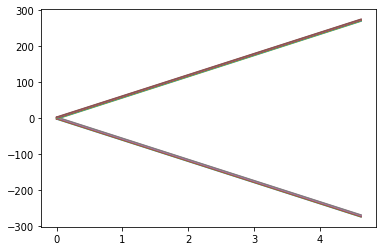

mean split:  0.04612157769837921


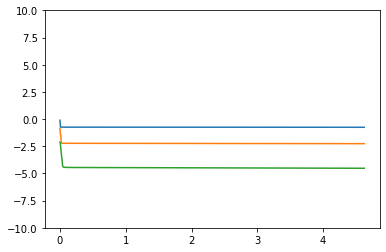

-0.7541095527527091
[0.00019257 0.00838395 0.00271788]
[[-21.32458959   6.50698854  22.02890644]
 [  6.50698854 -78.8558328  -32.03093895]
 [ 22.02890644 -32.03093895 -31.23321425]]
[[ 1.30159141e-04 -7.59825032e-04 -3.68444811e-04]
 [-7.59825032e-04 -5.96925752e-03 -1.17302846e-03]
 [-3.68444811e-04 -1.17302846e-03  1.87143106e-05]]


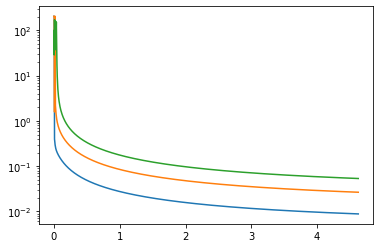

98308277580.97568


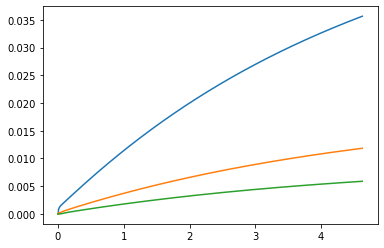

In [100]:
path="C:/Users/neb16/Documents/Uni/PHD/Experiments/Simulations/Spin_Hamiltonian/spin_hamiltonian/ion_params/"
gnd="Yb_CAWO.yml"
gnd='Er_YSO_site1_ground_wang.yml'

spinG=spin.hamilFromYAML(path+gnd,IOveride=7/2)
i,j=np.triu_indices(spinG.dim,k=1)

B=np.linspace(0,4.625,1000)+1E-12
Bu=np.array([0,0,1]).T

FT,VT=spinG.getEigFreq(np.outer(Bu,B))

Grad=spinG.gradient(VT)
Curv=spinG.curvature(VT,FT)


plt.plot(B,FT)
plt.show()
T=FT[:,i]-FT[:,j]
GT=Grad[:,i,:]-Grad[:,j,:]
CT=Curv[:,i,:]-Curv[:,j,:]

print('mean split: ',np.min(np.abs(np.diff(T[0,:]))))

plt.plot(B,T[:,[0,2,5]])
plt.ylim([-10,10])
plt.show()

plt.plot(B,np.linalg.norm(GT,axis=2)[:,[0,2,5]])
plt.yscale('log')

print(T[-1,0])
print(GT[-1,0,:])


print(CT[0,2,:,:])
print(CT[-1,0,:,:])

GN=np.linalg.norm(GT,axis=2)*1E9
CN=np.linalg.norm(CT,2,axis=(2,3))*1E9

dB=10E-6
plt.show()
T2=GN[:,[0,2,5]]*dB+CN[:,[0,2,5]]*np.power(dB,2)
#plt
plt.plot(B,np.pi/T2)

print(CN[0,2])

2 0 3
-3.0821520454990505 -3.185577767850898


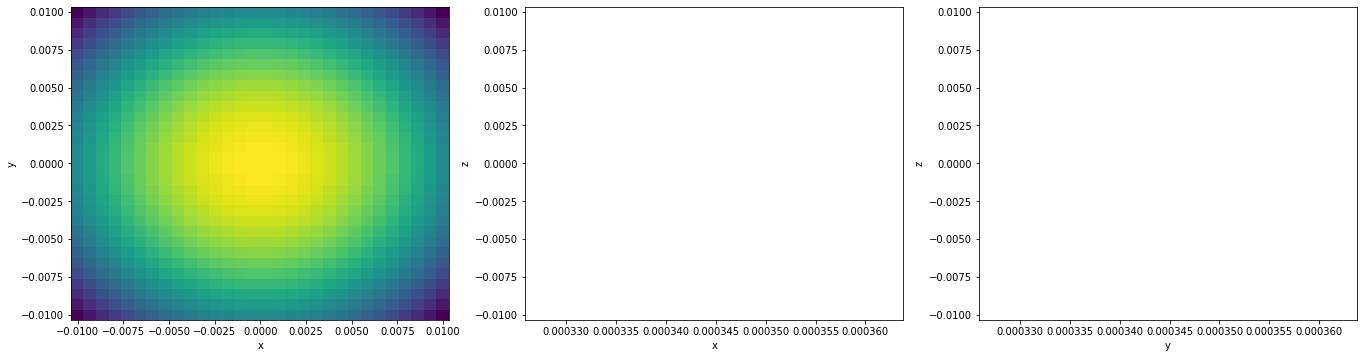

[0. 0. 0.]
0 0 1
-0.4640967782155343 -0.4642476117736223


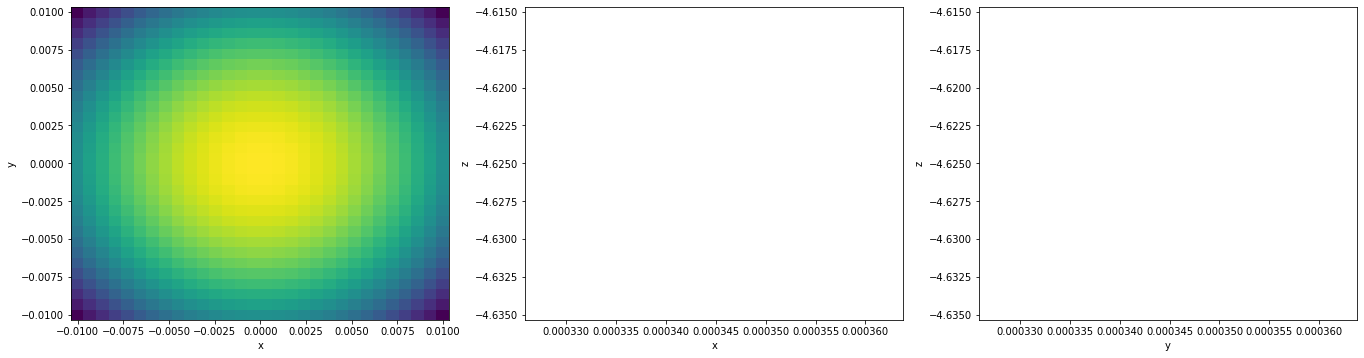

[ 0.     0.    -4.625]
5 2 3
-0.3249039447490958 -0.3251303574176916


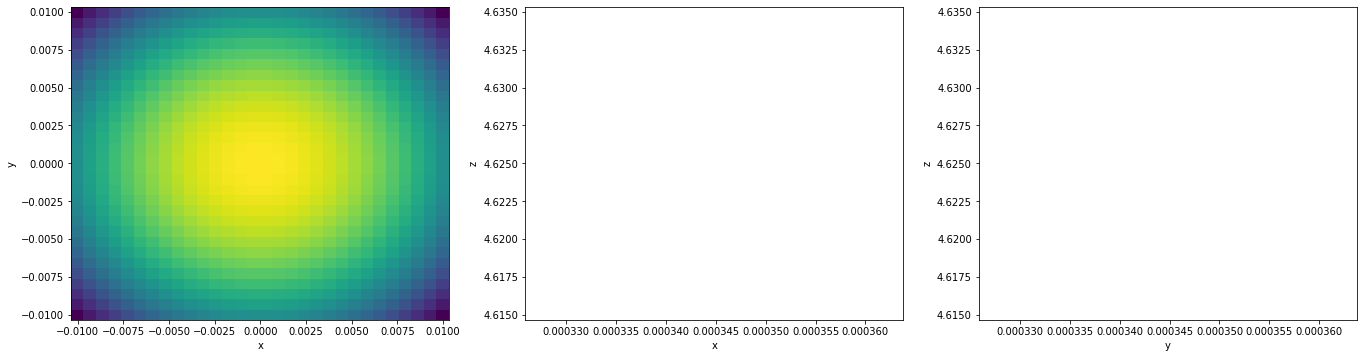

[0.    0.    4.625]


In [75]:
BZF=np.array([[0,0,0],[0,0,-4.625],[0,0,4.625]])
ts=[2,0,5]

rng=1E-2#E-3
pts=30



sli=pts//2
for k,B in enumerate(BZF):
    fig,axs=plt.subplots(1,3,figsize=(6.4*1.2*3,4.8*1.2*1))
    a1,a2,a3=axs.flatten()
    t=ts[k]
    X,Y,Z=np.meshgrid(*[np.linspace(b-rng,b+rng,pts) for b in B])

    Bsamp=np.vstack([X.flatten(),Y.flatten(),Z.flatten()])
    FT,VT=spinG.getEigFreq(Bsamp)
    FTT=(FT[:,i[t]]-FT[:,j[t]])
    print(t,i[t],j[t])
    FTT=FTT.reshape(X.shape)
    
    #p1=a1.imshow(FTT[:,:,pts//2])
    #FTTX=
    p1=a1.pcolor(X[:,:,sli],Y[:,:,sli],FTT[:,:,sli])
    a1.set_xlabel("x")
    a1.set_ylabel("y")

    a2.pcolor(X[:,sli,:].T,Z[:,sli,:].T,FTT[:,sli,:].T)

    print(np.max(FTT[:,sli,:]),np.min(FTT[:,sli,:]))

    #a2.imshow(FTT[:,sli,:])
    a2.set_xlabel("x")
    a2.set_ylabel("z")

    
    a3.pcolor(Y[sli,:,:],Z[sli,:,:],FTT[sli,:,:])
    a3.set_xlabel("y")
    a3.set_ylabel("z")
    #fig.colorbar(p1,ax=axs,cmap='viridis',fraction=0.1, label=r"Transition Frequency log$_{10}$(GHz)", shrink=1)

    
    plt.show()
    print(B)